# LLooM Analysis: Inciting Speech — Model Reasoning FN/FP

This notebook applies the LLooM pipeline to analyse **the model's own reasoning responses**
for misclassified samples from the INCITE dataset.

Each of the three binary classifiers is evaluated independently:

| Classifier | Response Field | Positive Label |
|---|---|---|
| Identity | `model_response_identity` | `Identity` |
| Imputed Misdeeds | `model_response_imputed_misdeeds` | `Imputed Misdeeds` |
| Exhortation | `model_response_exhortation` | `Exhortation` |

**FN/FP logic (per-classifier):**
- **FN:** `gold_label == pos_label` AND `pred != pos_label` → reasoning on a missed case
- **FP:** `gold_label != pos_label` AND `pred == pos_label` → reasoning on a false alarm

This yields **6 independent LLooM runs** saved to `outputs/lloom_reasoning/{classifier}/{fn|fp}/`.

Pipeline: **Distill → Embed → Cluster → Synthesize Concepts → Score → Visualize**

Models: **gpt-3.5-turbo** (distill + score), **gpt-4o-mini** (synthesize concepts).


In [1]:
!pip install -q -U requests pandas scikit-learn sentence-transformers \
umap-learn hdbscan tqdm wordcloud squarify networkx



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import re, json, os, time, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from wordcloud import WordCloud
import squarify



API_URL = "https://api.openai.com/v1/chat/completions"


/Users/yuvaraj/Desktop/VT_Work/sem4/research/lloom/classify_inciting_llm/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Configuration & Data Loading

Load `combined.jsonl`, then split into per-classifier FN/FP lists using the
**reasoning response** (`model_response_*`) as the text to analyse.


In [3]:
JSONL_PATH      = "combined2.jsonl"
BASE_OUTPUT_DIR = "outputs/lloom_reasoning"
os.makedirs(BASE_OUTPUT_DIR, exist_ok=True)

MODEL_DISTILL = "gpt-3.5-turbo"
MODEL_SYNTH   = "gpt-4o-mini"
MODEL_SCORE   = "gpt-3.5-turbo"

# ── Classifier config ──────────────────────────────────────────────────────
CLASSIFIERS = {
    "identity": {
        "response_field": "model_response_identity",
        "pred_field":     "pred_identity",
        "pos_label":      "Identity",
    },
    "imputed_misdeeds": {
        "response_field": "model_response_imputed_misdeeds",
        "pred_field":     "pred_imputed_misdeeds",
        "pos_label":      "Imputed Misdeeds",
    },
    "exhortation": {
        "response_field": "model_response_exhortation",
        "pred_field":     "pred_exhortation",
        "pos_label":      "Exhortation",
    },
}

# ── Seed phrases — per classifier × error type ────────────────────────────
SEEDS = {
    "identity": {
        "fn": (
            "patterns in identity-based inciting language that the model missed: "
            "subtle stereotyping, implicit group blame, indirect dehumanisation"
        ),
        "fp": (
            "patterns in non-identity text that the model wrongly flagged as identity-based: "
            "factual group references, counter-speech, neutral demographic mention"
        ),
    },
    "imputed_misdeeds": {
        "fn": (
            "patterns in imputed-misdeeds inciting language that the model missed: "
            "veiled blame attribution, indirect accusation, historically framed group crimes"
        ),
        "fp": (
            "patterns in non-imputed-misdeeds text that the model wrongly flagged: "
            "factual reporting of crimes, counter-speech, hypothetical or conditional framing"
        ),
    },
    "exhortation": {
        "fn": (
            "patterns in exhortation inciting language that the model missed: "
            "indirect calls to action, conditional imperatives, implicit mobilisation"
        ),
        "fp": (
            "patterns in non-exhortation text wrongly flagged: "
            "rhetorical questions, descriptive future tense, warnings or cautionary language"
        ),
    },
}

# ── Load JSONL ─────────────────────────────────────────────────────────────
def load_jsonl(path):
    records = []
    with open(path, "r") as f:
        content = f.read()
    decoder = json.JSONDecoder()
    idx = 0
    while idx < len(content):
        while idx < len(content) and content[idx] in " \t\n\r":
            idx += 1
        if idx >= len(content):
            break
        obj, end_idx = decoder.raw_decode(content, idx)
        records.append(obj)
        idx = end_idx
    return records

records = load_jsonl(JSONL_PATH)
print(f"Total records: {len(records)}")

# ── Build per-classifier FN/FP splits ─────────────────────────────────────
runs = {clf: {"fn": [], "fp": []} for clf in CLASSIFIERS}
skipped = {clf: {"fn": 0, "fp": 0} for clf in CLASSIFIERS}

for rec in records:
    gold = rec.get("gold_label", "")
    for clf_name, cfg in CLASSIFIERS.items():
        pred  = rec.get(cfg["pred_field"], "")
        resp  = rec.get(cfg["response_field"], "")
        if not resp or not resp.strip():
            continue

        if gold == cfg["pos_label"] and pred != cfg["pos_label"]:
            runs[clf_name]["fn"].append(resp)
        elif gold != cfg["pos_label"] and pred == cfg["pos_label"]:
            runs[clf_name]["fp"].append(resp)

# ── Summary table ──────────────────────────────────────────────────────────
print(f"\n{'Classifier':<22} {'FN':>6} {'FP':>6} {'Total':>8}")
print("-" * 45)
for clf_name in CLASSIFIERS:
    fn_n = len(runs[clf_name]["fn"])
    fp_n = len(runs[clf_name]["fp"])
    print(f"{clf_name:<22} {fn_n:>6} {fp_n:>6} {fn_n+fp_n:>8}")


Total records: 7000

Classifier                 FN     FP    Total
---------------------------------------------
identity                  162   2884     3046
imputed_misdeeds          467   1872     2339
exhortation               141   1177     1318


# Helper Functions

In [4]:
def clean_text(x):
    x = str(x).lower().strip()
    x = re.sub(r"http\S+|www\S+", " ", x)
    x = re.sub(r"&amp;|amp", " ", x)
    x = re.sub(r">+", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def safe_json_load(text):
    text = str(text).strip()
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)
    try:
        return json.loads(text)
    except Exception:
        pass
    m = re.search(r"\{.*\}", text, re.DOTALL)
    if m:
        return json.loads(m.group(0))
    raise ValueError(f"Could not parse JSON from response:\n{text[:1200]}")

def _openai_chat_raw(prompt: str, model_name: str, temperature) -> str:
    api_key = os.environ.get("OPENAI_API_KEY")
    if not api_key:
        raise RuntimeError("Set OPENAI_API_KEY (e.g. export OPENAI_API_KEY=sk-...)")
    headers = {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"}
    payload = {
        "model": model_name,
        "messages": [{"role": "user", "content": prompt}],
        "response_format": {"type": "json_object"},
    }
    if model_name.startswith("gpt-5") or model_name.startswith("o1") or model_name.startswith("o3"):
        payload["max_completion_tokens"] = 4096
        if model_name.startswith("gpt-5") or model_name.startswith("o1") or model_name.startswith("o3"):
            # O1/O3/GPT-5 variants handling
            pass
    else:
        payload["max_tokens"] = 4096
        if temperature is not None:
            payload["temperature"] = temperature
    resp = requests.post(API_URL, headers=headers, json=payload, timeout=120)
    if resp.status_code != 200:
        try:
            err = resp.json()
            msg = err.get("error", {}).get("message", str(err))
            typ = err.get("error", {}).get("type", "unknown")
            raise RuntimeError(f"API Error {resp.status_code} ({typ}): {msg}")
        except (ValueError, KeyError):
            raise RuntimeError(f"API Error {resp.status_code}: {resp.text[:500]}")
    return resp.json()["choices"][0]["message"]["content"]

def openai_chat_json(prompt, model_name, temperature=0.2):
    # gpt-4o-mini supports temperature; gpt-5/o1/o3 do not
    if model_name.startswith("gpt-5") or model_name.startswith("o1") or model_name.startswith("o3"):
        temperature = None
    text = _openai_chat_raw(prompt, model_name, temperature)
    return safe_json_load(text)


# Step 1: Distill reasoning texts into bullets

In [7]:
def distill_text_to_bullets(text, seed_phrase=""):
    prompt = f"""
You will read one piece of model reasoning about a social media post and summarise
its main analytical points into 2 to 4 short bullet phrases.

Rules:
- Each bullet must be 5 to 12 words
- Focus on the most salient analytical signals the model used
- Avoid generic phrases like "the model said" or "according to the text"
- Avoid repeating the same idea
- Keep wording concise
- Use the analytic focus only as a lens, not as a reason to invent content
- Return valid JSON only

Analytic focus:
{seed_phrase if seed_phrase else "None"}

Return format:
{{
  "bullets": ["...", "...", "..."]
}}

REASONING TEXT:
{text}
"""
    result = openai_chat_json(prompt, MODEL_DISTILL, temperature=0.3)
    return result.get("bullets", [])

def _distill_one(idx, txt, seed_phrase, max_retries=3, sleep_seconds=2):
    for attempt in range(max_retries):
        try:
            bullets = distill_text_to_bullets(txt, seed_phrase=seed_phrase)
            return {"orig_index": idx, "text": txt, "bullets": bullets, "error": None}
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(sleep_seconds * (attempt + 1))
            else:
                return {"orig_index": idx, "text": txt, "bullets": None, "error": str(e)}

def run_distillation(texts, seed_phrase="", max_workers=4, checkpoint_path="distill_ckpt.jsonl"):
    rows, done_ids = [], set()
    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, "r") as f:
            for line in f:
                rec = json.loads(line)
                rows.append(rec)
                done_ids.add(rec["orig_index"])

    items = [(i, t) for i, t in enumerate(texts) if i not in done_ids]
    print(f"Already distilled: {len(done_ids)}, Remaining: {len(items)}")

    if len(items) == 0:
        return pd.DataFrame(rows)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(_distill_one, idx, txt, seed_phrase): idx for idx, txt in items}
        with open(checkpoint_path, "a") as fout:
            for fut in tqdm(as_completed(futures), total=len(futures), desc="Distilling"):
                result = fut.result()
                fout.write(json.dumps(result) + "\n")
                fout.flush()
                rows.append(result)
    return pd.DataFrame(rows)


# Step 2: Expand bullets, embed, and cluster

In [8]:
def expand_distilled_rows(distilled_df):
    if distilled_df.empty:
        return pd.DataFrame()
    rows = []
    for _, row in distilled_df.iterrows():
        bullets = row.get("bullets")
        if isinstance(bullets, list):
            for b in bullets:
                rows.append({
                    "orig_index": row["orig_index"],
                    "text": row["text"],
                    "bullet": b,
                    "error": row.get("error"),
                })
        else:
            rows.append({
                "orig_index": row["orig_index"],
                "text": row["text"],
                "bullet": None,
                "error": row.get("error"),
            })
    return pd.DataFrame(rows)

embedder = SentenceTransformer("all-mpnet-base-v2")

def embed_and_cluster(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """UMAP + HDBSCAN on bullet embeddings; safe for empty or tiny sets."""
    if df.empty or "bullet" not in df.columns:
        print(f"[SKIP {name}] No bullet rows — distillation may have failed or DataFrame is empty.")
        out = df.copy()
        out["cluster"] = []
        return out
        
    bullets = df["bullet"].astype(str).tolist()
    n = len(bullets)
    if n == 0:
        print(f"[SKIP {name}] No bullet rows — distillation may have failed.")
        out = df.copy()
        out["cluster"] = np.full(n, -1, dtype=int)
        return out
    if n < 5:
        print(f"[WARN {name}] Only {n} bullets; skipping UMAP/HDBSCAN, assigning cluster 0.")
        out = df.copy()
        out["cluster"] = 0
        return out

    emb = embedder.encode(bullets, show_progress_bar=True, batch_size=64)
    umap_model = UMAP(
        n_components=min(15, n - 2),
        n_neighbors=min(15, n - 1),
        metric="cosine",
        random_state=42,
    )
    min_cs = min(12, max(2, n // 10))
    clusterer = HDBSCAN(
        min_cluster_size=min_cs,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    )
    red = umap_model.fit_transform(emb)
    out = df.copy()
    out["cluster"] = clusterer.fit_predict(red)
    print(f"{name} clusters:", out["cluster"].value_counts().head(15).to_dict())
    return out


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 17137.53it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Step 3: Synthesize concepts from clusters

In [9]:
def synthesize_concept(cluster_bullets, seed_phrase=""):
    bullets_text = "\n".join(f"- {b}" for b in cluster_bullets)
    prompt = f"""
You are a qualitative-analysis assistant.
Below are bullet-point summaries drawn from a single cluster of LLM reasoning texts
about social media posts. Propose ONE high-level concept that unifies these bullets.

Rules:
- concept_name: 3-8 word descriptive label
- description: 1-2 sentences explaining the concept
- inclusion_criteria: concrete criteria for deciding if a new reasoning text matches
- example_signals: 3 short phrases a matching reasoning text might contain

Analytic focus:
{seed_phrase if seed_phrase else "None"}

You must respond with valid json only (no markdown fences, no extra text).
Use this json object shape:
{{
  "concept_name": "...",
  "description": "...",
  "inclusion_criteria": "...",
  "example_signals": ["...", "...", "..."]
}}

BULLETS:
{bullets_text}
"""
    return openai_chat_json(prompt, MODEL_SYNTH)

def build_concepts(distilled_df, top_n=10, max_bullets=20, seed_phrase=""):
    if distilled_df.empty or "cluster" not in distilled_df.columns:
        return pd.DataFrame()
        
    concepts = []
    counts = distilled_df[distilled_df["cluster"] != -1]["cluster"].value_counts().head(top_n)
    for cid in tqdm(counts.index, desc="Synthesizing"):
        bullets = (
            distilled_df[distilled_df["cluster"] == cid]["bullet"]
            .dropna().tolist()[:max_bullets]
        )
        try:
            c = synthesize_concept(bullets, seed_phrase=seed_phrase)
            c["cluster"] = int(cid)
            c["cluster_size"] = int(counts[cid])
            concepts.append(c)
        except Exception as e:
            concepts.append({
                "cluster": int(cid),
                "cluster_size": int(counts[cid]),
                "concept_name": None,
                "error": str(e),
            })
    return pd.DataFrame(concepts)


# Step 4: Score every reasoning text against concepts

In [10]:
def score_text_against_concepts(text, concepts_df):
    if concepts_df.empty:
        return []
        
    valid = concepts_df.dropna(subset=["concept_name", "inclusion_criteria"])
    if valid.empty:
        return []
        
    block = [
        f"Concept: {c['concept_name']}\nCriteria: {c['inclusion_criteria']}"
        for _, c in valid.iterrows()
    ]
    prompt = f"""
You will read one piece of model reasoning about a social media post and decide
which concepts apply based on the criteria provided.

Return valid JSON only in this format:
{{
  "matches": [
    {{"concept_name": "...", "match": 0, "reason": "short reason"}}
  ]
}}

Important:
- Include one entry for every concept provided
- Use match = 1 only if the reasoning clearly fits the concept criteria
- Otherwise use match = 0

Concepts:
{chr(10).join(block)}

REASONING TEXT:
{text}
"""
    return openai_chat_json(prompt, MODEL_SCORE, temperature=0.1)["matches"]

def _score_one(idx, txt, concepts_df, max_retries=3, sleep_seconds=2):
    for attempt in range(max_retries):
        try:
            matches = score_text_against_concepts(txt, concepts_df)
            return {"orig_index": idx, "text": txt, "matches": matches, "error": None}
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(sleep_seconds * (attempt + 1))
            else:
                return {"orig_index": idx, "text": txt, "matches": None, "error": str(e)}

def score_dataset(texts, concepts_df, max_workers=4, checkpoint_path="score_ckpt.jsonl"):
    rows, done_ids = [], set()
    if os.path.exists(checkpoint_path):
        with open(checkpoint_path, "r") as f:
            for line in f:
                rec = json.loads(line)
                rows.append(rec)
                done_ids.add(rec["orig_index"])

    items = [(i, t) for i, t in enumerate(texts) if i not in done_ids]
    print(f"Already scored: {len(done_ids)}, Remaining: {len(items)}")

    if len(items) == 0:
        return pd.DataFrame(rows)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(_score_one, idx, txt, concepts_df): idx for idx, txt in items}
        with open(checkpoint_path, "a") as fout:
            for fut in tqdm(as_completed(futures), total=len(futures), desc="Scoring"):
                result = fut.result()
                fout.write(json.dumps(result) + "\n")
                fout.flush()
                rows.append(result)
    return pd.DataFrame(rows)

def expand_scored_rows(scored_df):
    if scored_df.empty:
        return pd.DataFrame()
        
    rows = []
    for _, row in scored_df.iterrows():
        matches = row.get("matches")
        if isinstance(matches, list):
            for m in matches:
                rows.append({
                    "orig_index":   row.get("orig_index"),
                    "text":         row.get("text"),
                    "concept_name": m.get("concept_name") if isinstance(m, dict) else None,
                    "match":        m.get("match") if isinstance(m, dict) else None,
                    "reason":       m.get("reason") if isinstance(m, dict) else None,
                    "error":        row.get("error"),
                })
        else:
            rows.append({
                "orig_index":   row.get("orig_index"),
                "text":         row.get("text"),
                "concept_name": None,
                "match":        None,
                "reason":       None,
                "error":        row.get("error"),
            })
    return pd.DataFrame(rows)


# Step 5: Visualisation helpers

In [11]:
def summarize_concept_coverage(scores_df):
    if scores_df.empty or "match" not in scores_df.columns:
        return pd.DataFrame()
    matched = scores_df[scores_df["match"] == 1].copy()
    by_concept = matched["concept_name"].value_counts().reset_index()
    by_concept.columns = ["concept_name", "matched_count"]
    return by_concept

def wrap_labels(labels, width=40):
    return ["\n".join(textwrap.wrap(str(l), width=width)) for l in labels]

def concept_barplot(df, title, top_n=10, save_path=None):
    if df.empty or "matched_count" not in df.columns:
        print(f"[SKIP barplot] No data for: {title}")
        return
    plot_df = df.sort_values("matched_count", ascending=False).head(top_n).iloc[::-1]
    wrapped = wrap_labels(plot_df["concept_name"], width=50)
    plt.figure(figsize=(13, 7))
    plt.barh(wrapped, plot_df["matched_count"])
    plt.yticks(fontweight="bold")
    plt.xlabel("Matched Count", fontweight="bold")
    plt.ylabel("Concept", fontweight="bold")
    plt.title(title, fontweight="bold")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

def concept_treemap(df, title, top_n=10, save_path=None):
    if df.empty or "matched_count" not in df.columns or len(df) < 2:
        print(f"[SKIP treemap] Not enough data for: {title}")
        return
    plot_df = df.sort_values("matched_count", ascending=False).head(top_n)
    labels = [
        "\n".join(textwrap.wrap(str(n), width=18)) + f"\n({c})"
        for n, c in zip(plot_df["concept_name"], plot_df["matched_count"])
    ]
    plt.figure(figsize=(14, 8))
    squarify.plot(sizes=plot_df["matched_count"], label=labels, alpha=0.8)
    plt.axis("off")
    plt.title(title, fontsize=15)
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

def concept_cooccurrence_heatmap(scores_df, title, top_n=10, save_path=None):
    if scores_df.empty or "match" not in scores_df.columns:
        print(f"[SKIP heatmap] No data for: {title}")
        return
    matched = scores_df[scores_df["match"] == 1].copy()
    if matched.empty:
        print(f"[SKIP heatmap] No matches for: {title}")
        return
    top_concepts = matched["concept_name"].value_counts().head(top_n).index.tolist()
    matched = matched[matched["concept_name"].isin(top_concepts)]
    if matched.empty:
        return
    try:
        binary = pd.crosstab(matched["orig_index"], matched["concept_name"])
        cooc = binary.T.dot(binary)
        plt.figure(figsize=(10, 8))
        plt.imshow(cooc, interpolation="nearest")
        plt.colorbar(label="Shared matched texts")
        plt.xticks(range(len(cooc.columns)),
                   ["\n".join(textwrap.wrap(c, 18)) for c in cooc.columns], rotation=90)
        plt.yticks(range(len(cooc.index)),
                   ["\n".join(textwrap.wrap(c, 18)) for c in cooc.index])
        plt.title(title)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, bbox_inches="tight")
        plt.show()
    except Exception as e:
        print(f"[SKIP heatmap] Error generating heatmap: {e}")


# Reusable Pipeline Function

In [12]:
def run_lloom_pipeline(
    texts,
    seed,
    output_dir,
    label,          # "fn" or "fp"
    top_n=10,
    max_workers=4,
):
    """
    Full LLooM pipeline on a list of reasoning texts.

    Steps:
      1. Distill texts → bullets (checkpointed)
      2. Embed bullets with SentenceTransformer → UMAP + HDBSCAN clusters
      3. Synthesize 1 concept per top cluster (LLM)
      4. Score every text against all concepts (checkpointed)
      5. Summarise concept coverage
      6. Produce bar chart, treemap, co-occurrence heatmap → saved as PDFs

    Args:
        texts      : list of reasoning strings to analyse
        seed       : analytic focus phrase for LLM prompts
        output_dir : directory to save all CSVs, checkpoints, and PDFs
        label      : "fn" or "fp" — used as filename prefix
        top_n      : number of clusters to synthesise concepts for
        max_workers: parallel API threads

    Returns:
        (concepts_df, scores_df, summary_df)
    """
    print(f"\n{'='*60}")
    print(f"  Pipeline: {label.upper()} | {len(texts)} texts | {output_dir}")
    print(f"{'='*60}")

    if len(texts) == 0:
        print(f"[SKIP] No {label} texts — nothing to run.")
        empty = pd.DataFrame()
        return empty, empty, empty

    os.makedirs(output_dir, exist_ok=True)

    # ── Step 1: Distill ────────────────────────────────────────────────────
    print(f"\n[Step 1] Distilling {len(texts)} reasoning texts → bullets ...")
    distilled_raw = run_distillation(
        texts,
        seed_phrase=seed,
        max_workers=max_workers,
        checkpoint_path=f"{output_dir}/{label}_distill_checkpoint.jsonl",
    )
    if not distilled_raw.empty:
        distilled_raw.to_csv(f"{output_dir}/{label}_distilled_raw.csv", index=False)

    # ── Step 2: Embed + cluster ────────────────────────────────────────────
    print(f"\n[Step 2] Expanding bullets, embedding, clustering ...")
    bullet_df  = expand_distilled_rows(distilled_raw)
    if not bullet_df.empty and "bullet" in bullet_df.columns:
        bullet_df  = bullet_df[bullet_df["bullet"].notna() & (bullet_df["bullet"] != "")]
    distilled  = embed_and_cluster(bullet_df, label.upper())
    if not distilled.empty:
        distilled.to_csv(f"{output_dir}/{label}_distilled_bullets.csv", index=False)

    # ── Step 3: Synthesize concepts ────────────────────────────────────────
    print(f"\n[Step 3] Synthesizing concepts from top {top_n} clusters ...")
    concepts = build_concepts(distilled, top_n=top_n, seed_phrase=seed)
    if not concepts.empty:
        concepts.to_csv(f"{output_dir}/{label}_concepts.csv", index=False)
        display(concepts[["cluster", "cluster_size", "concept_name", "description"]].head(top_n))

    # ── Step 4: Score ──────────────────────────────────────────────────────
    print(f"\n[Step 4] Scoring {len(texts)} texts against {len(concepts)} concepts ...")
    scores_raw = score_dataset(
        texts,
        concepts,
        max_workers=max_workers,
        checkpoint_path=f"{output_dir}/{label}_score_checkpoint.jsonl",
    )
    scores = expand_scored_rows(scores_raw)
    if not scores.empty:
        scores.to_csv(f"{output_dir}/{label}_scores.csv", index=False)
    print(f"  Scores shape: {scores.shape}")

    # ── Step 5: Summarise + visualise ─────────────────────────────────────
    print(f"\n[Step 5] Summarising + visualising ...")
    summary = summarize_concept_coverage(scores)
    if not summary.empty:
        summary.to_csv(f"{output_dir}/{label}_concept_summary.csv", index=False)
        display(summary)

        concept_barplot(
            summary,
            title=f"{label.upper()} — Top Concepts",
            save_path=f"{output_dir}/{label}_concepts_barplot.pdf",
        )
        concept_treemap(
            summary,
            title=f"{label.upper()} — Concept Treemap",
            save_path=f"{output_dir}/{label}_concepts_treemap.pdf",
        )
        concept_cooccurrence_heatmap(
            scores,
            title=f"{label.upper()} — Concept Co-occurrence",
            save_path=f"{output_dir}/{label}_cooccurrence_heatmap.pdf",
        )

    return concepts, scores, summary


# Run All 6 Pipelines

Iterates over all 3 classifiers × 2 error types (FN, FP) and runs the full
LLooM pipeline on the model's reasoning for each.

Output is saved to:
```
outputs/lloom_reasoning/
├── identity/
│   ├── fn/   ← Identity classifier false negatives
│   └── fp/   ← Identity classifier false positives
├── imputed_misdeeds/
│   ├── fn/
│   └── fp/
└── exhortation/
    ├── fn/
    └── fp/
```



  Pipeline: FN | 162 texts | outputs/lloom_reasoning/identity/fn

[Step 1] Distilling 162 reasoning texts → bullets ...
Already distilled: 0, Remaining: 162


Distilling: 100%|██████████| 162/162 [00:34<00:00,  4.69it/s]



[Step 2] Expanding bullets, embedding, clustering ...


Batches: 100%|██████████| 7/7 [00:01<00:00,  6.36it/s]
/Users/yuvaraj/Desktop/VT_Work/sem4/research/lloom/classify_inciting_llm/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


FN clusters: {-1: 162, 2: 68, 0: 50, 5: 40, 3: 39, 4: 28, 1: 13}

[Step 3] Synthesizing concepts from top 10 clusters ...


...

,cluster,cluster_size,concept_name,description
0,2,68,Absence of Identity-Based Incitement,This concept highlights the lack of identity-b...
1,0,50,Non-Stereotypical Discourse on Muslims,This concept captures the tendency to discuss ...
2,5,40,Targeted Discourse Over Group Stereotypes,This concept emphasizes the importance of addr...
3,3,39,Subtle Identity-Based Language Patterns,This concept encompasses the nuanced ways in w...
4,4,28,Political Discourse Over Identity Stereotypes,This concept emphasizes the prioritization of ...
5,1,13,Subtle Identity-Based Incitement,This concept encompasses the use of language t...



[Step 4] Scoring 162 texts against 6 concepts ...
Already scored: 0, Remaining: 162


Scoring: 100%|██████████| 162/162 [02:09<00:00,  1.25it/s]

  Scores shape: (959, 6)

[Step 5] Summarising + visualising ...


,concept_name,matched_count
0,Absence of Identity-Based Incitement,160
1,Targeted Discourse Over Group Stereotypes,150
2,Political Discourse Over Identity Stereotypes,140
3,Non-Stereotypical Discourse on Muslims,78
4,Subtle Identity-Based Language Patterns,18
5,Subtle Identity-Based Incitement,16


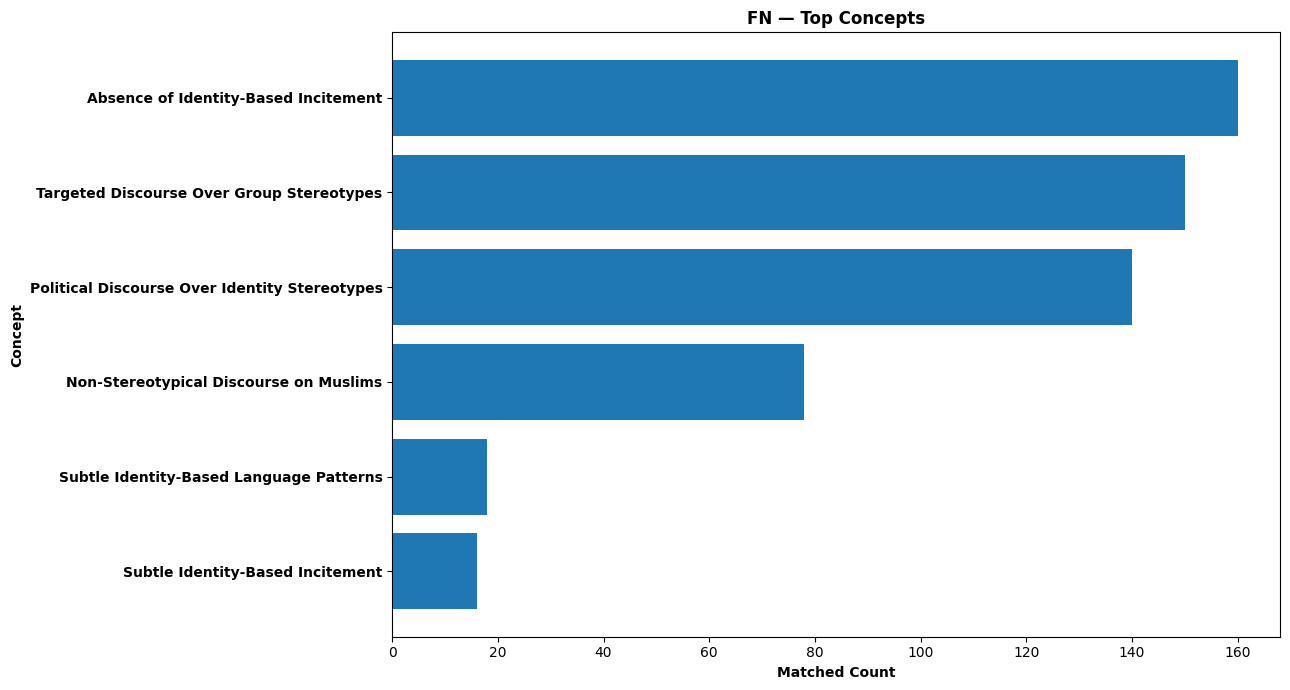

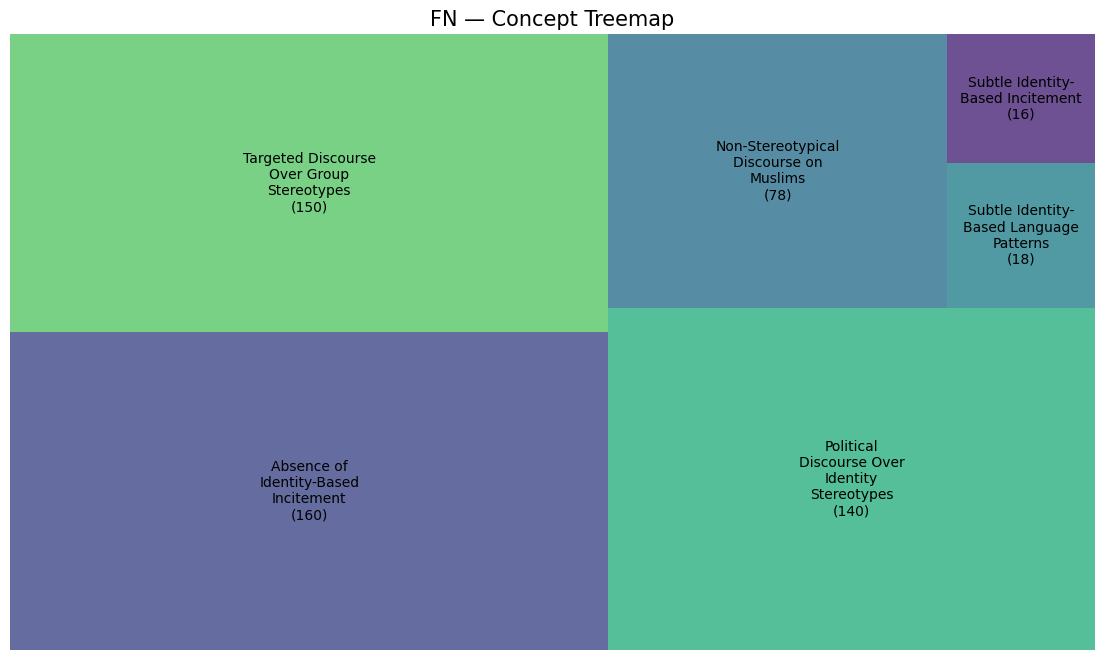

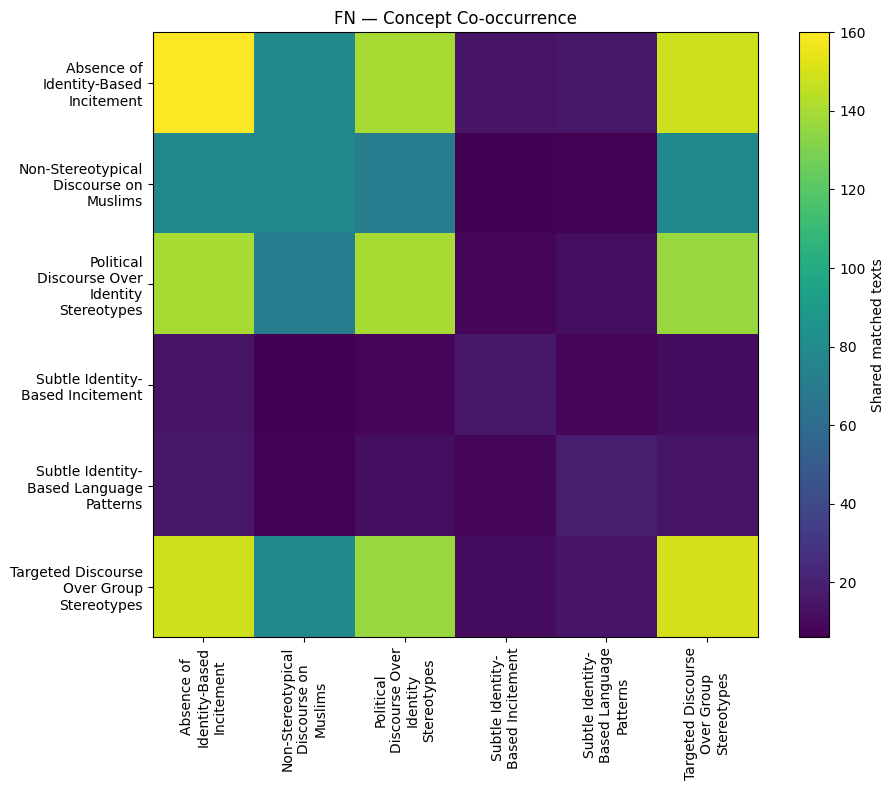


  Pipeline: FP | 2884 texts | outputs/lloom_reasoning/identity/fp

[Step 1] Distilling 2884 reasoning texts → bullets ...
Already distilled: 0, Remaining: 2884


Distilling: 100%|██████████| 2884/2884 [10:56<00:00,  4.39it/s]



[Step 2] Expanding bullets, embedding, clustering ...


Batches: 100%|██████████| 132/132 [00:14<00:00,  9.34it/s]
/Users/yuvaraj/Desktop/VT_Work/sem4/research/lloom/classify_inciting_llm/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


FP clusters: {-1: 2615, 7: 337, 107: 154, 110: 146, 14: 141, 66: 137, 129: 114, 141: 101, 70: 90, 78: 86, 99: 85, 28: 83, 126: 78, 1: 77, 113: 75}

[Step 3] Synthesizing concepts from top 10 clusters ...


Synthesizing: 100%|██████████| 10/10 [00:30<00:00,  3.08s/it]


,cluster,cluster_size,concept_name,description
0,7,337,Misclassification of Factual Group References,This concept addresses the tendency to misiden...
1,107,154,Historical Stereotyping of Muslims,This concept encompasses the tendency to stere...
2,110,146,Misidentified Stereotyping in Social Media,This concept addresses the misclassification o...
3,14,141,Misclassification of Non-Identity Critiques,This concept addresses the tendency to misiden...
4,66,137,Critique of Religious and Cultural Practices,This concept encompasses various forms of crit...
5,129,114,Stereotyping in Social Media Discourse,This concept focuses on the patterns of stereo...
6,141,101,Misattribution of Terrorism to Identity,This concept encompasses the erroneous linking...
7,70,90,Misinterpretation of Religious Contexts,This concept encompasses instances where socia...
8,78,86,Misrepresentation of Religious Texts,This concept encompasses the selective quoting...
9,99,85,Collective Blame and Stereotyping,This concept encompasses the tendency to attri...



[Step 4] Scoring 2884 texts against 10 concepts ...
Already scored: 0, Remaining: 2884


Scoring:  17%|█▋        | 500/2884 [07:30<35:14,  1.13it/s]  

In [ ]:
all_results = {}

for clf_name in CLASSIFIERS:
    all_results[clf_name] = {}
    for error_type in ["fn", "fp"]:
        texts    = runs[clf_name][error_type]
        seed     = SEEDS[clf_name][error_type]
        out_dir  = f"{BASE_OUTPUT_DIR}/{clf_name}/{error_type}"

        concepts, scores, summary = run_lloom_pipeline(
            texts=texts,
            seed=seed,
            output_dir=out_dir,
            label=error_type,
            top_n=10,
            max_workers=4,
        )
        all_results[clf_name][error_type] = {
            "concepts": concepts,
            "scores":   scores,
            "summary":  summary,
        }

print("\n✅ All 6 pipelines complete.")


# Cross-Classifier Summary

In [ ]:
print(f"\n{'Classifier':<22} {'Type':<6} {'Texts':>6} {'Concepts':>10} {'Top Concept'}")
print("-" * 90)

for clf_name in CLASSIFIERS:
    for error_type in ["fn", "fp"]:
        r = all_results[clf_name][error_type]
        n_texts    = len(runs[clf_name][error_type])
        concepts   = r["concepts"]
        summary    = r["summary"]

        n_concepts = len(concepts) if isinstance(concepts, pd.DataFrame) and not concepts.empty else 0
        top_concept = (
            summary.iloc[0]["concept_name"]
            if isinstance(summary, pd.DataFrame) and not summary.empty and "concept_name" in summary.columns
            else "—"
        )
        top_str = str(top_concept)[:50]
        print(f"{clf_name:<22} {error_type:<6} {n_texts:>6} {n_concepts:>10}   {top_str}")

print()
print("Output files per run:")
for clf_name in CLASSIFIERS:
    for error_type in ["fn", "fp"]:
        out_dir = f"{BASE_OUTPUT_DIR}/{clf_name}/{error_type}"
        if os.path.exists(out_dir):
            files = sorted(os.listdir(out_dir))
            print(f"  {clf_name}/{error_type}/  ({len(files)} files)")
            for fname in files:
                fpath = os.path.join(out_dir, fname)
                size_kb = os.path.getsize(fpath) / 1024
                print(f"    {fname:<45} {size_kb:>8.1f} KB")
